In [30]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv('/home/ashwini/Documents/DataPreprocessing/datas/titanic.csv')

In [53]:
# showing first 10 rows to understand data
df.head(10)   


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [54]:
 # checking the  rows and columns count
df.shape   


(891, 12)

In [55]:
# checking data types and missing values
df.info()   


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [56]:
 #  it shows the basic stats of numeric columns
df.describe() 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
# checking how many missing values in each column
df.isnull().sum() 


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [58]:
 # filling the  missing age with middle value
df['Age'] = df['Age'].fillna(df['Age'].median()) 

In [59]:
 # filling the  missing port with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 

In [60]:
# removing Cabin column cuz there are too many missing values
df = df.drop(columns=['Cabin'])  

In [61]:
#again checking null values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [62]:
# creating the  total family size column
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [63]:
# grouping fare into categories
df['FareGroup'] = pd.qcut(df['Fare'], 4, labels=['Low','Medium','High','Very High'])  

ANALYSIS


In [64]:
 # counting how many survived and not survived
df['Survived'].value_counts() 

Survived
0    549
1    342
Name: count, dtype: int64

In [65]:
 # survival rate based on gender
df.groupby('Sex')['Survived'].mean() 

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [66]:
# survival rate based on passenger class
df.groupby('Pclass')['Survived'].mean()  

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [67]:
# average age of survivors vs non-survivors
df.groupby('Survived')['Age'].mean()  

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [68]:
 # survival rate based on family size
df.groupby('FamilySize')['Survived'].mean() 

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

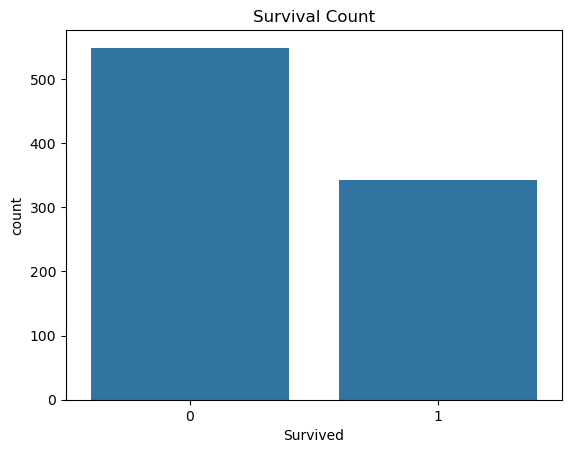

In [69]:
# showing  how many survived vs not
sns.countplot(data=df, x='Survived')
plt.title("Survival Count")  
plt.show()

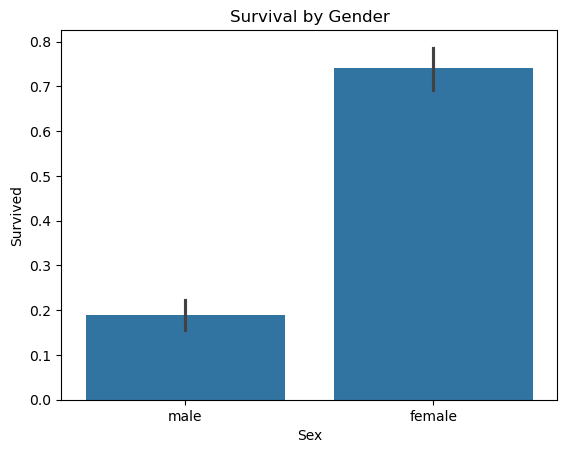

In [70]:
# comparing survival between male and female
sns.barplot(data=df, x='Sex', y='Survived')
plt.title("Survival by Gender")  
plt.show()

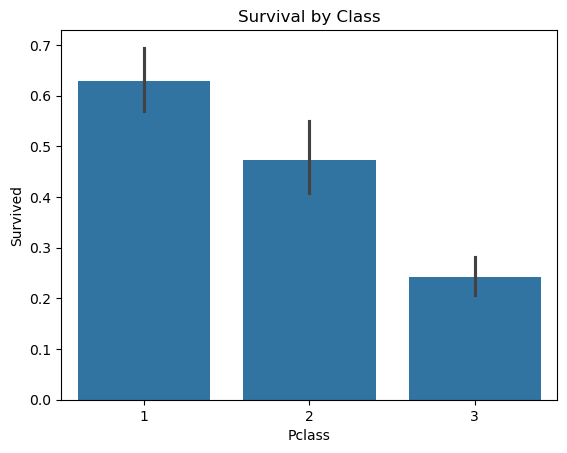

In [71]:
# checking the  survival rate by passenger class

sns.barplot(data=df, x='Pclass', y='Survived')
plt.title("Survival by Class")  
plt.show()

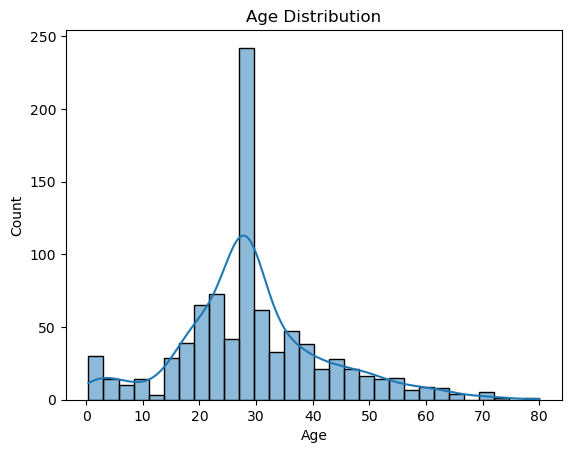

In [72]:
# show how passengers are distributed by age
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

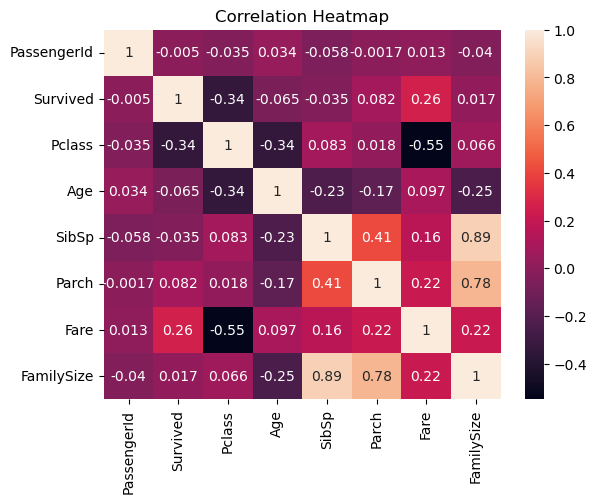

In [73]:
# showing relationship betn numeric features
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")  
plt.show()